In [1]:
from transformers import GPT2Tokenizer
from datasets import load_dataset

from itertools import chain

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

import os
import math

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

c:\Users\blash\miniconda3\envs\MoE\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\blash\miniconda3\envs\MoE\Lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


cuda


In [2]:
tokenizer: GPT2Tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

def tokenize(examples):
    return {"input_ids": [ids + [tokenizer.eos_token_id] for ids in tokenizer(examples["text"])["input_ids"]]}

In [3]:
dataset = load_dataset("roneneldan/TinyStories", split="train[:1%]").map(tokenize, batched=True)
train_data = torch.tensor(list(chain.from_iterable(dataset["input_ids"])), device=device)

val_ds = load_dataset("roneneldan/TinyStories", split="validation").map(tokenize, batched=True)
val_data = torch.tensor(list(chain.from_iterable(val_ds["input_ids"])), device=device)

def get_batch(data, batch_size, block_size):
    ix = torch.randint(len(data) - block_size - 1, (batch_size, 1), device=data.device)
    chunk = data[ix + torch.arange(block_size + 1, device=data.device)]
    return chunk[:, :-1], chunk[:, 1:]

In [4]:
class SpatialEmbedding(nn.Module):
    def __init__(self, vocab_size, embed_size, channels=1):
        super().__init__()

        self.shape = (channels, embed_size, embed_size)
        self.embed = nn.Embedding(vocab_size, channels * embed_size * embed_size)

        nn.init.normal_(self.embed.weight, std=0.02)

    def forward(self, x):
        return self.embed(x).unflatten(-1, self.shape)

In [5]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()

        self.n_heads = n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        q, k, v = self.qkv(x).unflatten(-1, (3, self.n_heads, -1)).permute(2, 0, 3, 1, 4)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        return self.proj(y.transpose(1, 2).flatten(2))

In [6]:
class DenseBlock(nn.Module):
    def __init__(self, d_model, n_heads, mult=4):
        super().__init__()

        self.ln_attn = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads)
        self.ln_mlp = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(nn.Linear(d_model, mult * d_model), nn.GELU(), nn.Linear(mult * d_model, d_model))

    def forward(self, h):
        h = h + self.attn(self.ln_attn(h))
        return h + self.mlp(self.ln_mlp(h))

In [7]:
def conv_block(c_in, c_out):
    return nn.Sequential(nn.Conv2d(c_in, c_out, 3, padding=1, padding_mode="circular"), nn.GELU())

class SpatialRouter(nn.Module):
    def __init__(self, expert_size, channels=(1, 32, 16), top_k=4):
        super().__init__()

        self.top_k = top_k
        self.resize = nn.AdaptiveAvgPool2d(expert_size)              # averages pixels instead of skipping them

        self.cnn = nn.Sequential(
            *[conv_block(a, b) for a, b in zip(channels, channels[1:])],
            nn.Conv2d(channels[-1], 1, 1),
        )

    def forward(self, x):
        logits = self.cnn(self.resize(x)).flatten(1).float()
        probs = logits.softmax(-1)                                    # full distribution, for the losses
        top, idx = logits.topk(self.top_k, -1)
        weights = torch.zeros_like(probs).scatter(-1, idx, top.softmax(-1))   # only top_k are non-zero
        return weights, probs

In [8]:
class ConvExperts(nn.Module):
    def __init__(self, num_experts, channels, hidden):
        super().__init__()

        self.K, self.C = num_experts, channels
        self.up = nn.Conv2d(channels, num_experts * hidden, 3, padding=1)
        self.down = nn.Conv2d(num_experts * hidden, num_experts * channels, 3, padding=1, groups=num_experts)

    def forward(self, x):                                            # x: (N, C, E, E)
        h = F.gelu(self.up(x))                                       # (N, K*H, E, E)
        return self.down(h).unflatten(1, (self.K, self.C))          # (N, K, C, E, E): every expert's output

In [9]:
def torus_sq_dist(E):
    i = torch.arange(E * E)
    r, c = i // E, i % E
    dr = (r[:, None] - r[None]).abs(); dc = (c[:, None] - c[None]).abs()
    dr = torch.minimum(dr, E - dr); dc = torch.minimum(dc, E - dc)
    return (dr ** 2 + dc ** 2).float()                              # (K, K) squared grid distance

def sample_outputs(y, n=256):
    y = y[torch.randint(y.shape[0], (n,), device=y.device)].flatten(2).float()    # (n, K, P)
    return y - y.mean(0, keepdim=True)                              # remove each expert's constant part (bias)

def topo_kernel_loss(y, target):
    # cosine similarity between experts should follow a Gaussian of their grid distance
    y = F.normalize(y, dim=-1)
    S = y @ y.transpose(1, 2)                                       # (n, K, K)
    off = ~torch.eye(S.shape[-1], dtype=torch.bool, device=S.device)
    return (S - target)[:, off].pow(2).mean()

def topo_ratio(y, mask):
    # monitoring only: neighbour distance / all-pairs distance (1.0 = no structure)
    sq = y.pow(2).sum(-1)
    d = (sq[:, :, None] + sq[:, None, :] - 2 * y @ y.transpose(1, 2)).clamp_min(0)
    K = d.shape[-1]
    return d[:, mask].mean() / (d.sum((1, 2)) / (K * (K - 1))).mean().clamp_min(1e-8)

class SpatialBlock(nn.Module):
    def __init__(self, embed_size, embed_channels, expert_size, router_channels, expert_hidden, n_heads, top_k, topo_sigma=1.0):
        super().__init__()

        d_model = embed_channels * embed_size ** 2
        self.shape = (embed_channels, embed_size, embed_size)

        self.ln_attn = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads)
        self.norm = nn.GroupNorm(1, embed_channels)
        self.router = SpatialRouter(expert_size, (embed_channels, *router_channels), top_k)
        self.experts = ConvExperts(expert_size ** 2, embed_channels, expert_hidden)

        d2 = torus_sq_dist(expert_size)
        self.register_buffer("nbr_mask", d2 == 1, persistent=False)
        self.register_buffer("topo_target", torch.exp(-d2 / (2 * topo_sigma ** 2)), persistent=False)

    def forward(self, h):                                        # h: (B, T, D) flattened grids
        B, T, D = h.shape
        h = h + self.attn(self.ln_attn(h))

        g = h.reshape(B * T, *self.shape)                        # (B*T, C, E, E)
        x = self.norm(g)
        weights, probs = self.router(x)
        y = self.experts(x)                                      # (B*T, K, C, E, E)
        g = g + (weights.to(y.dtype)[:, :, None, None, None] * y).sum(1)

        ys = sample_outputs(y)
        return (g.view(B, T, D), probs.view(B, T, -1), weights.view(B, T, -1),
                topo_kernel_loss(ys, self.topo_target), topo_ratio(ys, self.nbr_mask))


In [10]:
class SpatialMoE(nn.Module):
    def __init__(self, vocab_size, n_dense=1, n_spatial=2, block_size=128, embed_size=16, embed_channels=2,
                 expert_size=8, router_channels=(32, 16), expert_hidden=8, n_heads=8, top_k=4):
        super().__init__()

        self.expert_size = expert_size
        d_model = embed_channels * embed_size ** 2

        self.embedding = SpatialEmbedding(vocab_size, embed_size, embed_channels)
        self.pos = nn.Parameter(torch.randn(block_size, d_model) * 0.02)
        self.dense = nn.ModuleList([DenseBlock(d_model, n_heads) for _ in range(n_dense)])
        self.spatial = nn.ModuleList([
            SpatialBlock(embed_size, embed_channels, expert_size, router_channels, expert_hidden, n_heads, top_k)
            for _ in range(n_spatial)
        ])
        self.norm_f = nn.LayerNorm(d_model)

    def forward(self, ids):
        T = ids.shape[1]
        h = self.embedding(ids).flatten(2) + self.pos[:T]

        for block in self.dense:
            h = block(h)

        probs, weights, topo, ratio = [], [], [], []
        for block in self.spatial:
            h, p, w, t, r = block(h)
            probs.append(p); weights.append(w); topo.append(t); ratio.append(r)

        logits = self.norm_f(h) @ self.embedding.embed.weight.T
        if len(self.spatial) == 0:
            return logits, None
        return logits, {
            "probs": torch.stack(probs, 2),
            "weights": torch.stack(weights, 2),
            "topo": torch.stack(topo).mean(),                    # kernel loss (trained)
            "ratio": torch.stack(ratio).mean(),                  # neighbour/all ratio (monitored)
        }

In [11]:
n_dense = 1
n_spatial = 2
top_k = 4

batch_size = 16
block_size = 128
epochs = 1
lr = 1e-3

balance_coeff = 0.01
topo_coeff = 1.0
eval_every = 250
ckpt_every = 10_000
ckpt_dir = "checkpoints_v4/"

steps_per_epoch = len(train_data) // (batch_size * block_size)
max_steps = epochs * steps_per_epoch
print(f"{steps_per_epoch} steps per epoch")

os.makedirs(ckpt_dir, exist_ok=True)

2309 steps per epoch


In [12]:
model = SpatialMoE(tokenizer.vocab_size, n_dense=n_dense, n_spatial=n_spatial, block_size=block_size, top_k=top_k).to(device)
cmodel = torch.compile(model)

print(f"params: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

params: 31.10M


In [13]:
torch.manual_seed(0)
val_batches = [get_batch(val_data, batch_size, block_size) for _ in range(20)]

def compute_loss(x, y):
    with torch.autocast(device, dtype=torch.bfloat16, enabled=device == "cuda"):
        logits, aux = cmodel(x)
    ce = F.cross_entropy(logits.float().flatten(0, 1), y.flatten())
    if aux is None:
        zero = torch.zeros((), device=x.device)
        return ce, zero, zero, zero

    probs = aux["probs"].float()
    K = probs.shape[-1]
    dispatch = (aux["weights"] > 0).float().mean((0, 1)) / top_k
    importance = probs.mean((0, 1))
    balance = (K * (dispatch * importance).sum(-1)).mean() - 1
    return ce, balance, aux["topo"], aux["ratio"]

@torch.no_grad()
def evaluate():
    model.eval()
    ces, ratios = [], []
    for x, y in val_batches:
        ce, _, _, ratio = compute_loss(x, y)
        ces.append(ce.item()); ratios.append(ratio.item())
    model.train()
    return sum(ces) / len(ces), sum(ratios) / len(ratios)

def save_checkpoint(step):
    torch.save({
        "model": model.state_dict(),
        "opt": opt.state_dict(),
        "step": step,
        "history": history,
    }, ckpt_dir + f"step_{step}.pt")

def wsd_lr(step, warmup=200, decay_frac=0.15):
    decay_start = int(max_steps * (1 - decay_frac))
    if step < warmup:
        return lr * (step + 1) / warmup
    if step < decay_start:
        return lr
    return lr * (1 - (step - decay_start) / (max_steps - decay_start))

In [14]:
decay    = [p for p in model.parameters() if p.dim() >= 2]
no_decay = [p for p in model.parameters() if p.dim() < 2]
opt = torch.optim.AdamW([
    {"params": decay, "weight_decay": 0.1},
    {"params": no_decay, "weight_decay": 0.0},
], lr=lr, fused=True)

history = {"train": [], "val": []}

for step in range(max_steps):
    for g in opt.param_groups:
        g["lr"] = wsd_lr(step)

    ce, bal, topo, _ = compute_loss(*get_batch(train_data, batch_size, block_size))
    loss = ce + balance_coeff * bal + topo_coeff * topo

    opt.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()

    history["train"].append(ce.item())
    if step % eval_every == 0:
        val_ce, val_ratio = evaluate()
        history["val"].append((step, val_ce))
        print(f"step {step}: train {ce.item():.3f}  val {val_ce:.3f}  balance {bal.item():.3f}  "
              f"topo {topo.item():.4f}  ratio {val_ratio:.3f}  lr {opt.param_groups[0]['lr']:.2e}")
        
    if (step + 1) % ckpt_every == 0:
        save_checkpoint(step + 1)

W1006 11:51:49.863000 4836 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] [1/0] NOTE: Redirects are currently not supported in Windows or MacOs.
W1006 11:51:52.968000 4836 site-packages\torch\_inductor\utils.py:1731] [3/0_1] Not enough SMs to use max_autotune_gemm mode
c:\Users\blash\miniconda3\envs\MoE\Lib\site-packages\torch\_inductor\lowering.py:7836: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(
c:\Users\blash\miniconda3\envs\MoE\Lib\site-packages\torch\_inductor\lowering.py:7836: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(


step 0: train 10.904  val 10.871  balance 0.017  topo 0.0441  ratio 1.003  lr 5.00e-06
step 250: train 3.951  val 3.872  balance 0.001  topo 0.0024  ratio 0.523  lr 1.00e-03


KeyboardInterrupt: 

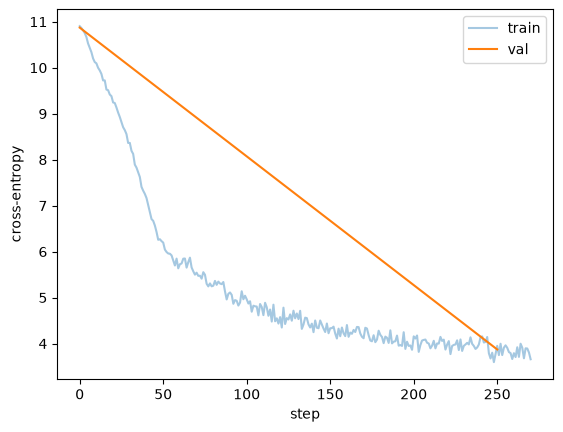

In [15]:
plt.plot(history["train"], alpha=0.4, label="train")
plt.plot(*zip(*history["val"]), label="val")
plt.xlabel("step"); plt.ylabel("cross-entropy"); plt.legend()
plt.show()

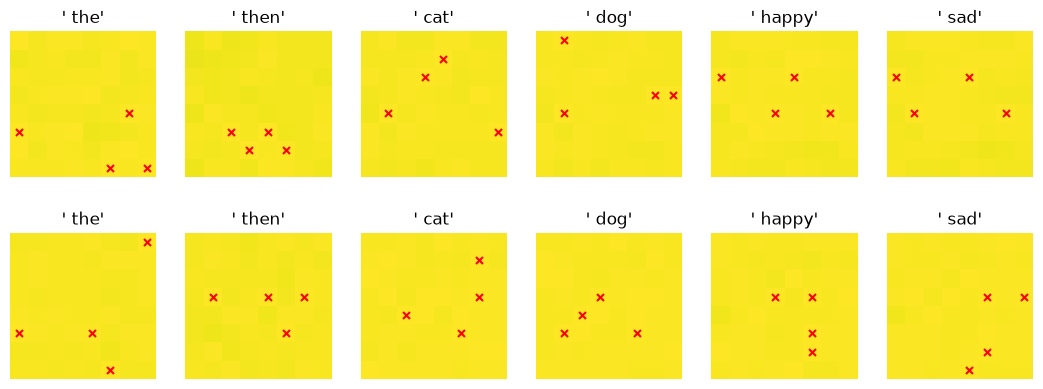

In [16]:
words = [" the", " then", " cat", " dog", " happy", " sad"]
ids = torch.tensor([[tokenizer.encode(w)[0] for w in words]], device=device)
model.eval()
with torch.no_grad():
    _, aux = model(ids)
model.train()

p, w = aux["probs"][0].float().cpu(), aux["weights"][0].float().cpu()
L, E = p.shape[1], model.expert_size
fig, axes = plt.subplots(L, len(words), figsize=(2.2 * len(words), 2.4 * L), squeeze=False)
for l in range(L):
    for ax, word, pm, wm in zip(axes[l], words, p[:, l], w[:, l]):
        ax.imshow(pm.view(E, E), vmin=0)
        r, c = torch.nonzero(wm.view(E, E) > 0, as_tuple=True)
        ax.scatter(c, r, marker="x", color="red", s=25)
        ax.set_title(repr(word)); ax.axis("off")
plt.show()

In [ ]:
@torch.no_grad()
def generate(prompt, max_new_tokens=128, temperature=1.0, top_k=50):
    model.eval()
    ids = torch.tensor([tokenizer.encode(prompt)], device=device)

    for _ in range(max_new_tokens):
        logits, _ = model(ids[:, -block_size:])
        logits = logits[:, -1] / temperature                     # scores for the next token
        v, _ = torch.topk(logits, top_k)
        logits[logits < v[:, [-1]]] = -float("inf")              # keep only the top_k tokens
        next_id = torch.multinomial(logits.softmax(-1), 1)
        ids = torch.cat([ids, next_id], dim=1)
        if next_id.item() == tokenizer.eos_token_id:             # end of story
            break

    model.train()
    return tokenizer.decode(ids[0])

print(generate("Once upon a time, there was a man named ben"))

Once upon a time, there was a man named ben. He loved to dance and play with himself. One day, Spot's mom said, "Mama, kids. That was too tired, Timmy's car?"

But Timmy was very glad when Timmy loved to see, Timmymy's mommy told Timmy's mommy's mommy told him that he he got brave, he started to join the beach.<|endoftext|>


In [17]:
x, _ = val_batches[0]
model.eval()
with torch.no_grad():
    _, aux = model(x)
model.train()   

for l in range(aux["probs"].shape[2]):
    p = aux["probs"][:, :, l].float()
    share = (aux["weights"][:, :, l] > 0).float().mean((0, 1)) / top_k
    print(f"layer {l}: top prob {p.max(-1).values.mean():.2f}, "
          f"{(share > 0).sum()}/{share.numel()} experts used, "
          f"busiest expert gets {share.max() * 100:.1f}% of picks (even = {100 / share.numel():.1f}%)")

layer 0: top prob 0.02, 64/64 experts used, busiest expert gets 5.0% of picks (even = 1.6%)
layer 1: top prob 0.02, 64/64 experts used, busiest expert gets 3.8% of picks (even = 1.6%)


In [18]:
def torus_dist(a, b, E):
    dr = (a[:, None] // E - b[None] // E).abs(); dc = (a[:, None] % E - b[None] % E).abs()
    return torch.minimum(dr, E - dr) + torch.minimum(dc, E - dc)

@torch.no_grad()
def picks(word, layer):
    _, aux = model(torch.tensor([[tokenizer.encode(word)[0]]], device=device))
    return torch.nonzero(aux["weights"][0, 0, layer] > 0).flatten().cpu()

model.eval()
E = model.expert_size
for a, b in [(" cat", " dog"), (" happy", " sad"), (" cat", " the"), (" dog", " then")]:
    for l in range(n_spatial):
        pa, pb = picks(a, l), picks(b, l)
        d = torus_dist(pa, pb, E)
        print(f"layer {l}  {a!r:9} vs {b!r:9} shared {len(set(pa.tolist()) & set(pb.tolist()))}/{top_k}  "
              f"avg distance to nearest {d.min(1).values.float().mean():.2f}")
model.train()

layer 0  ' cat'    vs ' dog'    shared 2/4  avg distance to nearest 0.75
layer 1  ' cat'    vs ' dog'    shared 2/4  avg distance to nearest 1.25
layer 0  ' happy'  vs ' sad'    shared 1/4  avg distance to nearest 1.50
layer 1  ' happy'  vs ' sad'    shared 2/4  avg distance to nearest 1.50
layer 0  ' cat'    vs ' the'    shared 0/4  avg distance to nearest 3.00
layer 1  ' cat'    vs ' the'    shared 0/4  avg distance to nearest 2.25
layer 0  ' dog'    vs ' then'   shared 0/4  avg distance to nearest 1.50
layer 1  ' dog'    vs ' then'   shared 0/4  avg distance to nearest 1.25


SpatialMoE(
  (embedding): SpatialEmbedding(
    (embed): Embedding(50257, 512)
  )
  (dense): ModuleList(
    (0): DenseBlock(
      (ln_attn): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=512, out_features=1536, bias=True)
        (proj): Linear(in_features=512, out_features=512, bias=True)
      )
      (ln_mlp): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=512, out_features=2048, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=2048, out_features=512, bias=True)
      )
    )
  )
  (spatial): ModuleList(
    (0-1): 2 x SpatialBlock(
      (ln_attn): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=512, out_features=1536, bias=True)
        (proj): Linear(in_features=512, out_features=512, bias=True)
      )
      (norm): GroupNorm(1, 2,

In [ ]:
@torch.no_grad()
def expert_outputs(x):
    model.eval()
    h = model.embedding(x).flatten(2) + model.pos[:x.shape[1]]
    for b in model.dense:
        h = b(h)
    outs = []
    for b in model.spatial:
        B, T, D = h.shape
        g = (h + b.attn(b.ln_attn(h))).reshape(B * T, *b.shape)
        outs.append(b.experts(b.norm(g)))                         # (B*T, K, C, E, E)
        h, *_ = b(h)
    model.train()
    return outs
x, _ = val_batches[0]
d2 = torus_sq_dist(model.expert_size).to(device)

for l, y in enumerate(expert_outputs(x)):
    block = model.spatial[l]
    ys = sample_outputs(y)                                        # (n, K, P), each expert's constant part removed

    diff = ys - ys.mean(1, keepdim=True)                          # what makes each expert different
    s2 = torch.linalg.svdvals(diff).pow(2)                        # (n, min(K, P))
    eff_dims = (s2.sum(-1) ** 2 / s2.pow(2).sum(-1)).mean()
    spread = (diff.pow(2).sum((1, 2)) / ys.pow(2).sum((1, 2)).clamp_min(1e-8)).mean()
    ratio = topo_ratio(ys, block.nbr_mask)

    bias = block.experts.down.bias.view(block.experts.K, -1).float()[None]   # (1, K, C)
    bias_topo = topo_ratio(bias, block.nbr_mask)

    yn = F.normalize(ys, dim=-1)
    S = (yn @ yn.transpose(1, 2)).mean(0)                         # (K, K) average cosine similarity
    profile = "  ".join(
        f"d²={v}: {S[d2 == v].mean():+.2f} (want {block.topo_target[d2 == v][0]:.2f})"
        for v in [1, 2, 4, 9, 32]
    )

    print(f"layer {l}: experts differ along ~{eff_dims:.1f} directions, "
          f"{spread * 100:.1f}% of output differs between experts, "
          f"ratio {ratio:.2f}, bias-only topo {bias_topo:.2f}")
    print(f"         similarity by grid distance: {profile}")

TypeError: topo_ratio() got an unexpected keyword argument 'n'